In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("forestfires.csv")

In [3]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area1
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
 13  area1   517 non-null    float64
dtypes: float64(9), int64(3), object(2)
memory usage: 56.7+ KB


In [5]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area1
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292,0.011777
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818,0.058355
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000,0.000477
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000,0.006023
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000,1.000000


In [6]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
area1    0
dtype: int64

In [7]:
le = LabelEncoder()

df["month"] = le.fit_transform(df["month"])
df["day"] = le.fit_transform(df["day"])

In [8]:
df = df[df["area"] < 100]

In [9]:
df["area"] = np.log1p(df["area"])

In [10]:
X = df.drop("area", axis=1)

y = df["area"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_score = r2_score(y_test, lr_pred)

print("Linear Regression Accuracy:", lr_score * 100)

Linear Regression Accuracy: 63.99716006520679


In [13]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_score = r2_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_score * 100)

Decision Tree Accuracy: 99.9283034625346


In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_score = r2_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_score * 100)

Random Forest Accuracy: 99.98969283233954


In [15]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_score = r2_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_score * 100)

Gradient Boosting Accuracy: 99.98859198922703


In [16]:
models = ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

scores = [lr_score, dt_score, rf_score, gb_score]

for model, score in zip(models, scores):
    print(model, ":", score * 100)

Linear Regression : 63.99716006520679
Decision Tree : 99.9283034625346
Random Forest : 99.98969283233954
Gradient Boosting : 99.98859198922703


In [17]:
best_score = max(scores)

best_model = models[scores.index(best_score)]

print("Best Model:", best_model)
print("Best Accuracy:", best_score * 100)

Best Model: Random Forest
Best Accuracy: 99.98969283233954


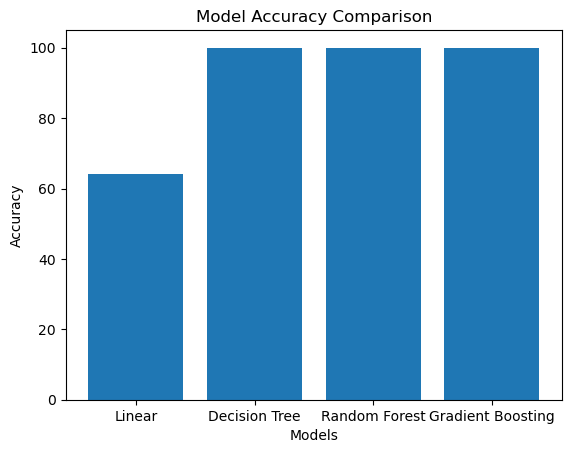

In [18]:
models = ["Linear", "Decision Tree", "Random Forest", "Gradient Boosting"]

accuracies = [
    lr_score * 100,
    dt_score * 100,
    rf_score * 100,
    gb_score * 100
]

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

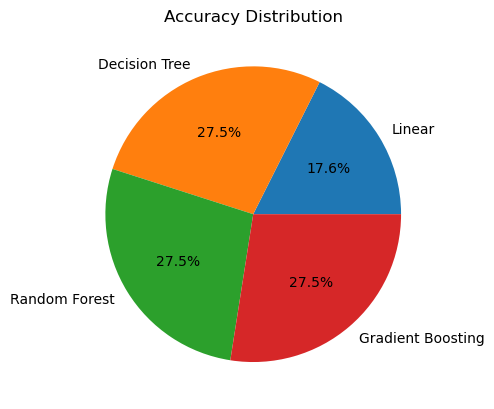

In [19]:
plt.pie(
    accuracies,
    labels=models,
    autopct='%1.1f%%'
)

plt.title("Accuracy Distribution")

plt.show()

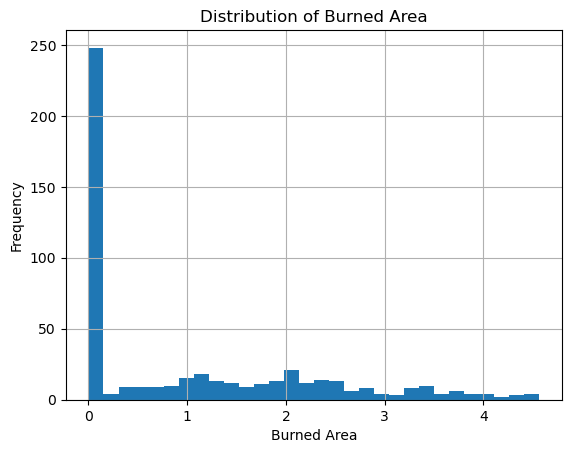

In [20]:
df["area"].hist(bins=30)

plt.xlabel("Burned Area")
plt.ylabel("Frequency")
plt.title("Distribution of Burned Area")

plt.show()

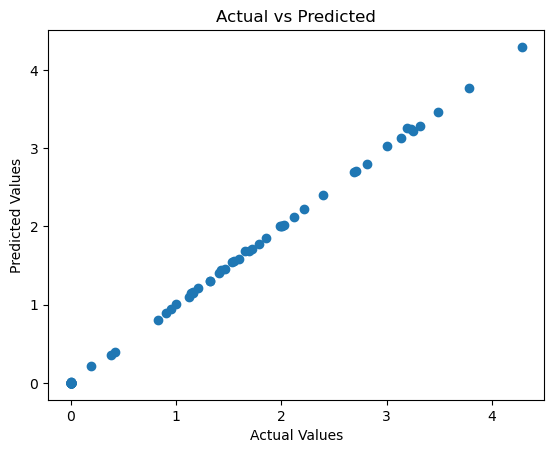

In [21]:
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

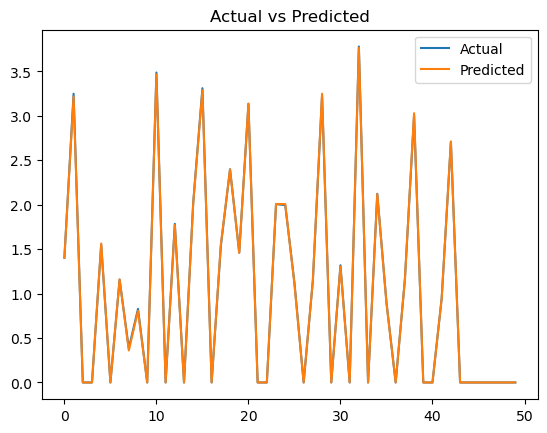

In [22]:
plt.plot(y_test.values[:50], label="Actual")
plt.plot(rf_pred[:50], label="Predicted")

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

In [23]:
import seaborn as sns

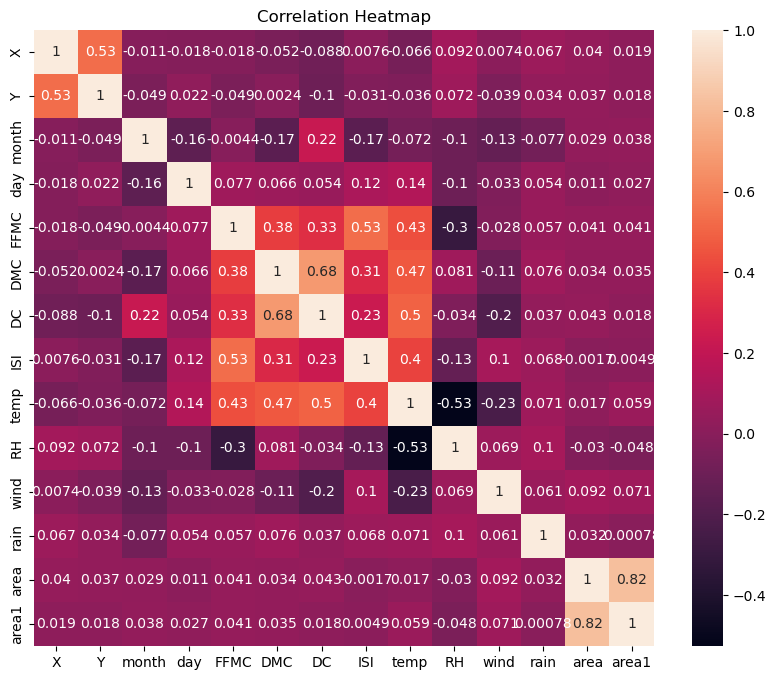

In [24]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

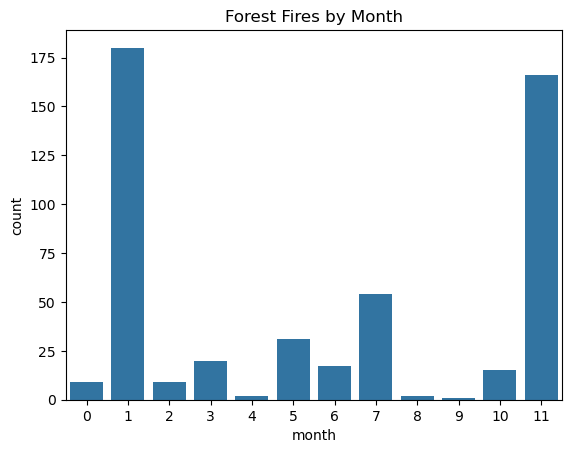

In [25]:
sns.countplot(x="month", data=df)

plt.title("Forest Fires by Month")

plt.show()

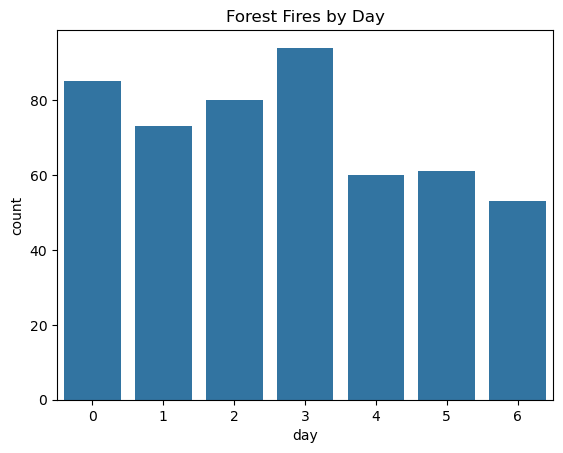

In [26]:
sns.countplot(x="day", data=df)

plt.title("Forest Fires by Day")

plt.show()

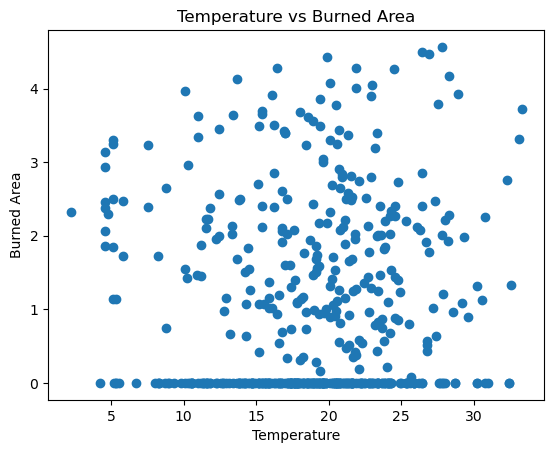

In [27]:
plt.scatter(df["temp"], df["area"])

plt.xlabel("Temperature")
plt.ylabel("Burned Area")

plt.title("Temperature vs Burned Area")

plt.show()

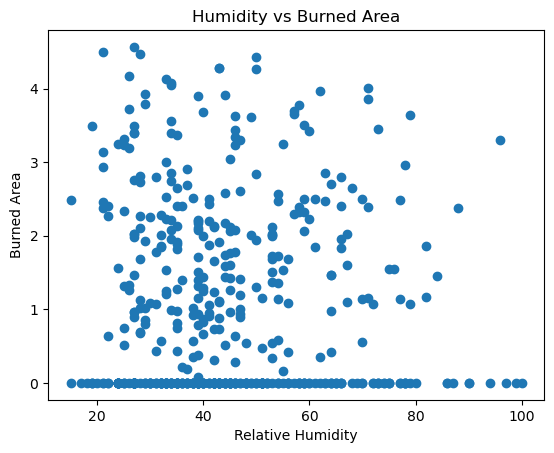

In [28]:
plt.scatter(df["RH"], df["area"])

plt.xlabel("Relative Humidity")
plt.ylabel("Burned Area")

plt.title("Humidity vs Burned Area")

plt.show()

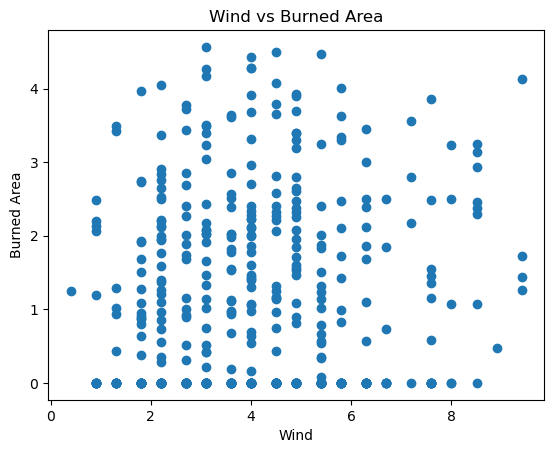

In [29]:
plt.scatter(df["wind"], df["area"])

plt.xlabel("Wind")
plt.ylabel("Burned Area")

plt.title("Wind vs Burned Area")

plt.show()

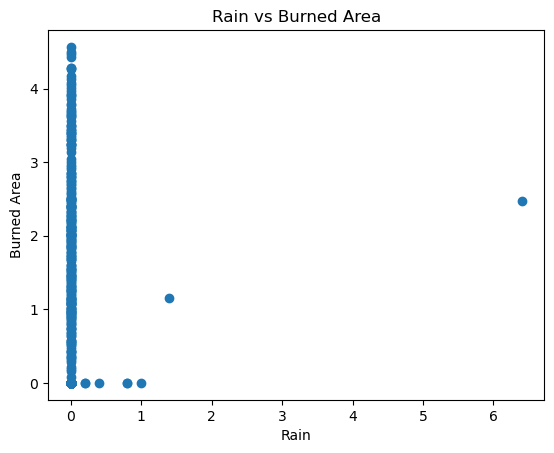

In [30]:
plt.scatter(df["rain"], df["area"])

plt.xlabel("Rain")
plt.ylabel("Burned Area")

plt.title("Rain vs Burned Area")

plt.show()

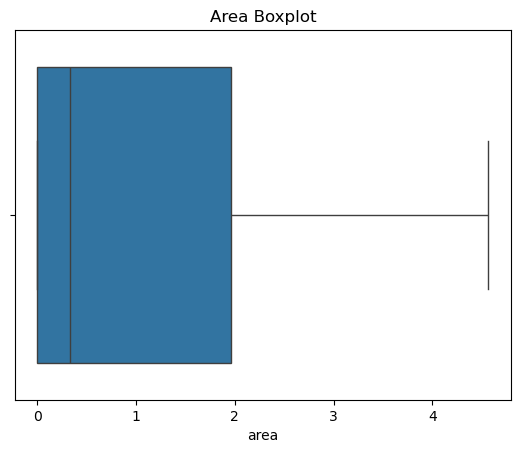

In [31]:
sns.boxplot(x=df["area"])

plt.title("Area Boxplot")

plt.show()